[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bernardorivas/wael/blob/main/notebooks/example4_conley_morse.ipynb)

# Example 4. A multistable 3-network

A three-gene regulatory network with parameters sampled from DSGRN region **2472287**, whose Morse graph exhibits multistability and oscillation simultaneously. We run the pipeline on a noise-free version. 

1. Least-squares fits `(L, U, theta)` with the steepness `d` and decay `gamma` fixed. 
2. the PINN learns all parameters jointly with the network weights. 

Each parameter recovery is scored by region membership rather than parameter error.

In [23]:
# DSGRN and DSGRN_utils (the rook-field code) provide the topological validation used throughout.
# numpy, scipy, matplotlib and torch are already available on Colab and in a standard local setup.
%pip install -q DSGRN
%pip install -q tqdm git+https://github.com/marciogameiro/DSGRN_utils.git

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.stats import qmc
import torch, torch.nn as nn
import DSGRN, DSGRN_utils
np.set_printoptions(precision=3, suppress=True)

# Train on a GPU when one is available: CUDA on Colab, MPS on Apple silicon, otherwise CPU.
# Note that MPS is single precision only, so CUDA is set to float32 for reproducibility.
if torch.cuda.is_available():
    DEVICE, TORCH_DTYPE = torch.device('cuda'), torch.float32
elif torch.backends.mps.is_available():
    DEVICE, TORCH_DTYPE = torch.device('mps'), torch.float32
else:
    DEVICE, TORCH_DTYPE = torch.device('cpu'), torch.float64
torch.set_default_dtype(TORCH_DTYPE)
print('torch device:', DEVICE, '| dtype:', TORCH_DTYPE)

torch device: mps | dtype: torch.float32


### Hill functions

The production is built from Hill functions
\begin{equation}
f^+(x,L,U,\theta,d) = L + (U-L) \frac{x^d}{x^d+\theta^d}, \quad
f^-(x,L,U,\theta,d) = L + (U-L) \frac{\theta^d}{x^d+\theta^d}
\end{equation}
where `L` and `U` are the lower and upper values, `theta` is a threshold, and `d` is the steepness. This network mixes activation (`f+`) and repression (`f-`), and each gene's production is a multilinear combination of its incoming Hill factors.

We define `hill_act` and `hill_rep` below, both in NumPy for simulation and in torch for the PINN's physics loss.

In [25]:
# --- Hill production functions: smooth switches (gamma normalized to 1) ---
def hill_act(x, L, U, th, d):   # activating: low L -> high U as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * xd / (td + xd)

def hill_rep(x, L, U, th, d):   # repressing: high U -> low L as x rises
    xd = np.power(x, d); td = np.power(th, d)
    return L + (U - L) * td / (td + xd)

In [26]:
# --- the same two functions in torch (used inside the network's physics loss) ---
def hill_act_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * xd / (td + xd)

def hill_rep_t(x, L, U, th, d):
    xd = x.clamp(min=1e-9).pow(d); td = th.pow(d)
    return L + (U - L) * td / (td + xd)

## 1. Model and DSGRN region (node 2472287)

The network is

$$\dot{x}_1=-x_1+f^+(x_1)\,f^-(x_2)\,f^-(x_3),\quad
  \dot{x}_2=-x_2+f^-(x_1)\,f^+(x_2),\quad
  \dot{x}_3=-x_3+f^-(x_2)\,f^+(x_3),$$

with DSGRN specification `1 : (1)(~2)(~3)`, `2 : (~1)(2)`, `3 : (~2)(3)` which yields seven tuples `(L, U, theta)`. 

The ground truth parameters are in the parameter region 2472287, with membership tested via DSGRN's `par_index_from_sample`.

In [27]:
NET_SPEC = "1 : (1)(~2)(~3)\n2 : (~1)(2)\n3 : (~2)(3)\n"
_net = DSGRN.Network(NET_SPEC); _pg = DSGRN.ParameterGraph(_net)
TARGET = 2472287
GAMMA, DATA_D = 1.0, 15.0

# seven edges,, each edge's sign, and each node's inputs
EDGES   = [(0,0),(1,0),(2,0),(0,1),(1,1),(1,2),(2,2)]
SIGN    = {(0,0):'+',(1,0):'-',(2,0):'-',(0,1):'-',(1,1):'+',(1,2):'-',(2,2):'+'}
FACTORS = {0:[(0,0),(1,0),(2,0)], 1:[(0,1),(1,1)], 2:[(1,2),(2,2)]}
KEYS    = [f'{c}{i}{j}' for (i,j) in EDGES for c in 'LUT']

# true parameters, an in-region sample of node 2472287
_L  = np.array([[0.979,  0.6728, 0.0   ], [0.7319, 0.0952, 1.0318], [1.11,   0.0, 0.075 ]])
_U  = np.array([[1.7861, 1.8833, 0.0   ], [1.2686, 2.1213, 3.1529], [2.9441, 0.0, 2.3182]])
_Th = np.array([[1.3848, 1.937,  0.0   ], [0.9001, 0.4126, 2.0089], [5.4074, 0.0, 0.2915]])
P = {f'{c}{i}{j}': m[i,j] for c, m in [('L',_L),('U',_U),('T',_Th)] for (i,j) in EDGES}
for (i, j) in EDGES: P[f'd{i}{j}'] = DATA_D   # per-edge steepness (all equal for the ground truth)
P['g'] = GAMMA

def production(node, x, p):                  # product of the node's Hill factors
    r = 1.0
    for (i, j) in FACTORS[node]:
        f = hill_act if SIGN[(i, j)] == '+' else hill_rep
        r = r * f(x[i], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
    return r

def rhs(t, x, p, g=GAMMA):
    return [-g*x[k] + production(k, x, p) for k in range(3)]

def to_matrices(p):                          # parameter dict -> DSGRN L, U, T matrices
    L = np.zeros((3, 3)); U = np.zeros((3, 3)); T = np.zeros((3, 3))
    for (i, j) in EDGES: L[i,j], U[i,j], T[i,j] = p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}']
    return L, U, T
def region_of(p):                            # parameters -> DSGRN region index (-1 if outside)
    return DSGRN.par_index_from_sample(_pg, *to_matrices(p))
def in_region(p):
    return region_of(p) == TARGET

print('The parameter graph has size:', _pg.size())
print('Which region are the ground truth parameters in?', 'Region', region_of(P))

The parameter graph has size: 3600000
Which region are the ground truth parameters in? Region 2472287


## 2. Synthetic data

64 initial conditions are drawn by Latin-hypercube sampling over the state box and integrated over a long horizon. 

The data is noise-free.

box upper bounds: [8.01, 4.79, 8.77] | trajectories: 1024


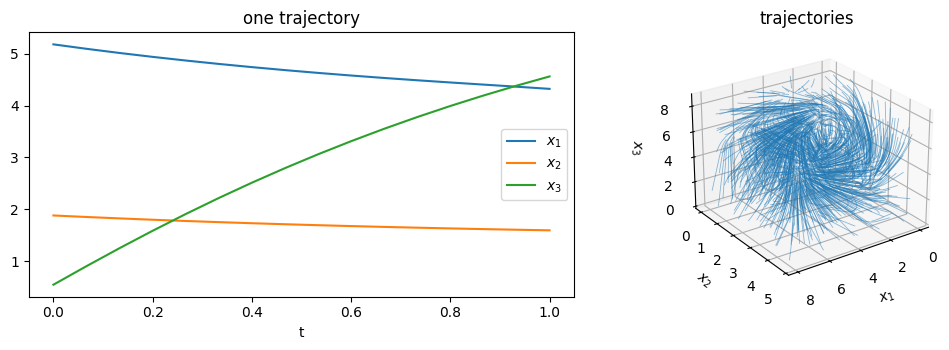

In [61]:
def max_production(p):   # upper bound for production
    U = to_matrices(p)[1]
    return np.array([np.prod([sum(U[s, k] for s in fac) for fac in _net.logic(k)]) for k in range(3)])

MARGIN = 1.2
box_hi = MARGIN * max_production(P)
n_ic   = 1024
T, n = 1.0, 16
traj_color = 'tab:blue'
x0s = qmc.scale(qmc.LatinHypercube(d=3, seed=0, optimization='random-cd').random(n_ic),
                [0.0, 0.0, 0.0], box_hi).tolist()
ts, xs = [], []
for x0 in x0s:
    t = np.linspace(0.0, T, n)
    sol = solve_ivp(rhs, (0.0, T), x0, t_eval=t, args=(P,), rtol=1e-10, atol=1e-12)
    ts.append(t); xs.append(sol.y.T)
print('box upper bounds:', np.round(box_hi, 2).tolist(), '| trajectories:', n_ic)

fig = plt.figure(figsize=(11, 3.6))
ax0 = fig.add_subplot(1, 2, 1)
for k, lab in enumerate(['$x_1$', '$x_2$', '$x_3$']): ax0.plot(ts[0], xs[0][:, k], label=lab)
ax0.set_xlabel('t'); ax0.legend(); ax0.set_title('one trajectory')
axp = fig.add_subplot(1, 2, 2, projection='3d')
for y in xs: axp.plot(y[:, 0], y[:, 1], y[:, 2], color=traj_color, lw=.6, alpha=.5)
axp.view_init(elev=25, azim=55)
axp.set_xlabel('$x_1$'); axp.set_ylabel('$x_2$'); axp.set_zlabel('$x_3$')
axp.set_title('trajectories')
plt.tight_layout(); plt.show()

## 3. Least squares

Least squares over the twenty-one parameters, with `d`, `gamma` fixed. Slopes are estimated by finite differences and the parameters chosen so the vector field matches them at the data. 

There is no ODE solver in the loop, and region membership is checked with DSGRN.

In [62]:
def ls_recover(ts, xs, g=GAMMA, n_starts=6, seed=0):
    X  = np.vstack(xs)
    DX = np.vstack([np.gradient(y, t, axis=0) for t, y in zip(ts, xs)])
    scale = np.maximum(np.std(DX, axis=0), 1e-6)

    # Per edge: L, delta (U = L + delta), T, and steepness d.
    eps = 1e-8
    upper = 25.0

    def unpack(z):
        p = {}
        for m, (i, j) in enumerate(EDGES):
            L, delta, T, d = z[4*m:4*m+4]
            p[f'L{i}{j}'] = L
            p[f'U{i}{j}'] = L + delta
            p[f'T{i}{j}'] = T
            p[f'd{i}{j}'] = d
        p['g'] = g
        return p

    def resid(z):
        p = unpack(z)
        cols = []
        for k in range(3):
            r = np.ones(X.shape[0])
            for (i, j) in FACTORS[k]:
                f = hill_act if SIGN[(i, j)] == '+' else hill_rep
                r = r * f(X[:, i], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
            cols.append((DX[:, k] - (-g*X[:, k] + r)) / scale[k])
        return np.concatenate(cols)

    z_base = np.array([v for _ in EDGES for v in (0.3, 2.0 - 0.3, 1.0, 8.0)], dtype=float)
    lb = np.array([v for _ in EDGES for v in (0.0, eps, eps, 0.25)], dtype=float)
    ub = np.array([v for _ in EDGES for v in (upper, upper, upper, 80.0)], dtype=float)

    starts = [z_base]
    rng = np.random.default_rng(seed)
    for _ in range(max(0, n_starts - 1)):
        z = z_base.copy()
        for m, _edge in enumerate(EDGES):
            z[4*m + 0] = rng.uniform(0.05, 2.5)  # L
            z[4*m + 1] = rng.uniform(0.05, 4.0)  # delta = U - L
            z[4*m + 2] = rng.uniform(0.05, 6.0)  # T
            z[4*m + 3] = rng.uniform(2.0, 20.0)  # d
        starts.append(np.clip(z, lb, ub))

    best = None
    for z0 in starts:
        s = least_squares(
            resid, z0, bounds=(lb, ub), max_nfev=40000, loss='soft_l1',
            x_scale='jac', ftol=1e-10, xtol=1e-10, gtol=1e-10,
        )
        if best is None or s.cost < best.cost:
            best = s

    return unpack(best.x)

p_ls = ls_recover(ts, xs)
print('Does LS land in region', TARGET, '?', in_region(p_ls), '| region', region_of(p_ls))

Does LS land in region 2472287 ? True | region 2472287


Largest LS parameter errors


,key,edge,param,ground_truth,p_ls,signed_error,abs_error,rel_error_%
0,U10,1->0,U,1.2686,3.5039,+2.2353,2.2353,176.2
1,U20,2->0,U,2.9441,1.3106,-1.6335,1.6335,55.5
2,L10,1->0,L,0.7319,2.0267,+1.2948,1.2948,176.9
3,U01,0->1,U,1.8833,3.0905,+1.2072,1.2072,64.1
4,U11,1->1,U,2.1213,1.2903,-0.8310,0.8310,39.2
5,L20,2->0,L,1.1100,0.4965,-0.6135,0.6135,55.3
6,L01,0->1,L,0.6728,1.1067,+0.4339,0.4339,64.5
7,U00,0->0,U,1.7861,1.4489,-0.3372,0.3372,18.9
8,U12,1->2,U,3.1529,2.9271,-0.2258,0.2258,7.2
9,L00,0->0,L,0.9790,0.7922,-0.1868,0.1868,19.1


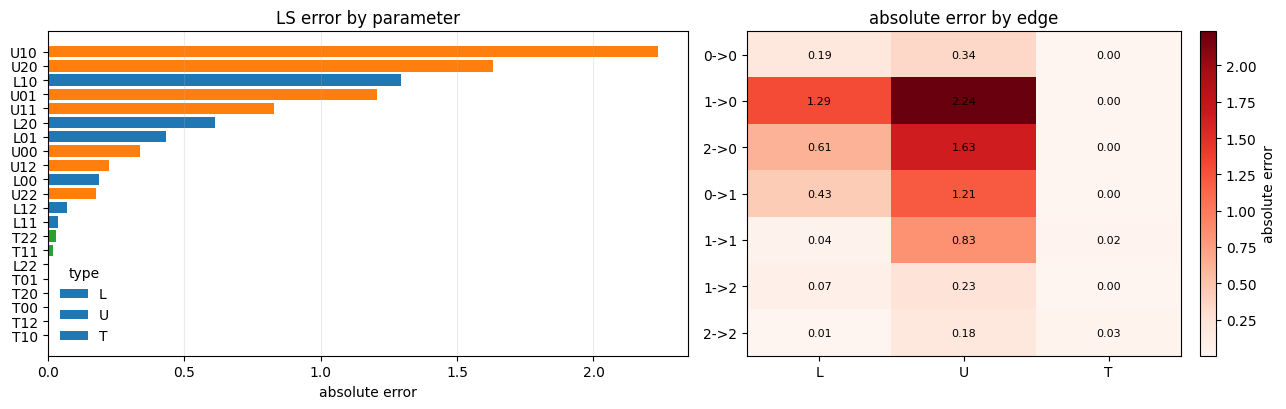

fixed scalars: {'d': {'ground_truth': 15.0, 'p_ls': 15.0, 'abs_error': 0.0}, 'g': {'ground_truth': 1.0, 'p_ls': 1.0, 'abs_error': 0.0}}


In [63]:
import pandas as pd
from IPython.display import display

rows = []
for k in KEYS:
    c, i, j = k[0], int(k[1]), int(k[2])
    truth = float(P[k])
    est = float(p_ls[k])
    err = est - truth
    rows.append({
        'key': k,
        'edge': f'{i}->{j}',
        'param': c,
        'ground_truth': truth,
        'p_ls': est,
        'signed_error': err,
        'abs_error': abs(err),
        'rel_error_%': 100 * abs(err) / abs(truth) if truth != 0 else np.nan,
    })

err_df = pd.DataFrame(rows)
err_sorted = err_df.sort_values('abs_error', ascending=False).reset_index(drop=True)

print('Largest LS parameter errors')
display(
    err_sorted.style
    .format({
        'ground_truth': '{:.4f}',
        'p_ls': '{:.4f}',
        'signed_error': '{:+.4f}',
        'abs_error': '{:.4f}',
        'rel_error_%': '{:.1f}',
    })
    .background_gradient(subset=['abs_error'], cmap='Reds')
)

fig, (ax0, ax1) = plt.subplots(
    1, 2, figsize=(13, 4.2),
    gridspec_kw={'width_ratios': [1.35, 1]}
)

colors = err_sorted['param'].map({
    'L': 'tab:blue',
    'U': 'tab:orange',
    'T': 'tab:green',
})

ax0.barh(err_sorted['key'], err_sorted['abs_error'], color=colors)
ax0.invert_yaxis()
ax0.set_xlabel('absolute error')
ax0.set_title('LS error by parameter')
ax0.grid(axis='x', alpha=0.25)

for param, color in {'L': 'tab:blue', 'U': 'tab:orange', 'T': 'tab:green'}.items():
    ax0.barh([], [], color=color, label=param)
ax0.legend(title='type', frameon=False)

edge_order = [f'{i}->{j}' for i, j in EDGES]
heat = err_df.pivot(index='edge', columns='param', values='abs_error').loc[edge_order, ['L', 'U', 'T']]

im = ax1.imshow(heat.values, cmap='Reds', aspect='auto')
ax1.set_xticks(range(3), heat.columns)
ax1.set_yticks(range(len(edge_order)), edge_order)
ax1.set_title('absolute error by edge')

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        ax1.text(c, r, f'{heat.iloc[r, c]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='absolute error')
plt.tight_layout()
plt.show()

print('fixed scalar (gamma):', {'g': {'ground_truth': P['g'], 'p_ls': p_ls['g'], 'abs_error': abs(p_ls['g'] - P['g'])}})

## 4. PINN

The surrogate `u(t, x0)` is a feed-forward network of time and the initial condition.

The PINN learns the seven per-edge tuples `(L, U, theta, d)` jointly with the network; the decay `gamma` is fixed at 1. 

In [64]:
class PINN(nn.Module):
    def __init__(self, m, param_init, T, hidden=96, depth=4, fourier_k=0, eps=1e-6):
        super().__init__()
        self.m, self.T, self.fourier_k, self.eps = m, T, fourier_k, eps
        in_dim = (2*fourier_k if fourier_k > 0 else 1) + m

        if fourier_k > 0:
            self.register_buffer(
                'freqs',
                2*np.pi*torch.arange(1, fourier_k+1, dtype=torch.get_default_dtype())
            )

        layers, d0 = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d0, hidden), nn.Tanh()]
            d0 = hidden
        layers += [nn.Linear(d0, m)]
        self.net = nn.Sequential(*layers)

        # Internal physical parameters are positive via softplus.
        # For each edge, train L and delta=U-L, then expose U=L+delta.
        self.raw = nn.ParameterDict()
        for (i, j) in EDGES:
            L0 = max(float(param_init[f'L{i}{j}']), eps)
            U0 = max(float(param_init[f'U{i}{j}']), L0 + eps)
            D0 = max(U0 - L0, eps)
            T0 = max(float(param_init[f'T{i}{j}']), eps)

            self.raw[f'L{i}{j}'] = nn.Parameter(self._inv_pos(L0))
            self.raw[f'D{i}{j}'] = nn.Parameter(self._inv_pos(D0))
            self.raw[f'T{i}{j}'] = nn.Parameter(self._inv_pos(T0))

        for (i, j) in EDGES:
            self.raw[f'd{i}{j}'] = nn.Parameter(self._inv_pos(param_init.get(f'd{i}{j}', DATA_D)))

    def _inv_pos(self, value):
        y = torch.tensor(
            max(float(value) - self.eps, self.eps),
            dtype=torch.get_default_dtype()
        )
        return torch.log(torch.expm1(y))

    def _pos(self, key):
        return torch.nn.functional.softplus(self.raw[key]) + self.eps

    def phys_params(self):
        p = {}
        for (i, j) in EDGES:
            L = self._pos(f'L{i}{j}')
            D = self._pos(f'D{i}{j}')
            p[f'L{i}{j}'] = L
            p[f'U{i}{j}'] = L + D
            p[f'T{i}{j}'] = self._pos(f'T{i}{j}')

        for (i, j) in EDGES:
            p[f'd{i}{j}'] = self._pos(f'd{i}{j}')
        return p

    def _feat(self, t):
        tn = t / self.T
        if self.fourier_k > 0:
            return torch.cat([torch.sin(self.freqs*tn), torch.cos(self.freqs*tn)], dim=1)
        return tn

    def forward(self, t, x0):
        return self.net(torch.cat([self._feat(t), x0], dim=1))


def rhs_t(x, p):
    cols = []
    for node in range(3):
        r = torch.ones_like(x[:, :1])
        for (i, j) in FACTORS[node]:
            f = hill_act_t if SIGN[(i, j)] == '+' else hill_rep_t
            r = r * f(x[:, i:i+1], p[f'L{i}{j}'], p[f'U{i}{j}'], p[f'T{i}{j}'], p[f'd{i}{j}'])
        cols.append(-x[:, node:node+1] + r)
    return torch.cat(cols, dim=1)


def build_tensors(ts, xs, x0s):
    t_d  = np.concatenate([t[:, None] for t in ts])
    x_d  = np.vstack(xs)
    x0_d = np.vstack([np.tile(x0, (len(t), 1)) for x0, t in zip(x0s, ts)])
    t_ic = np.zeros((len(x0s), 1))
    x_ic = np.array(x0s, dtype=float)

    to = lambda a: torch.tensor(a, dtype=torch.get_default_dtype(), device=DEVICE)
    return (to(t_d), to(x0_d), to(x_d), to(t_ic), to(x_ic))


def fit_pinn(model, data, rhs_t, steps=6000, lr=2e-3, w=(50.0, 10.0, 1.0), log=1000):
    t_d, x0_d, x_d, t_ic, x_ic = data
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for it in range(steps):
        opt.zero_grad()

        loss_data = ((model(t_d, x0_d) - x_d)**2).mean()

        tc = t_d.clone().requires_grad_(True)
        u = model(tc, x0_d)
        du = torch.cat([
            torch.autograd.grad(u[:, j].sum(), tc, create_graph=True)[0]
            for j in range(model.m)
        ], dim=1)

        loss_phys = ((du - rhs_t(u, model.phys_params()))**2).mean()
        loss_ic = ((model(t_ic, x_ic) - x_ic)**2).mean()
        loss = w[0]*loss_data + w[1]*loss_phys + w[2]*loss_ic

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        opt.step()

        if log and it % log == 0:
            print(f'  step {it:5d}  data {loss_data.item():.2e}  phys {loss_phys.item():.2e}')

    return model

In [65]:
init = {k: ({'L': 0.3, 'U': 2.0, 'T': 1.0}[k[0]]) for k in KEYS}
init.update({f'd{i}{j}': DATA_D for (i, j) in EDGES})

torch.manual_seed(0)

model = PINN(
    m=3,
    param_init=init,
    T=T,
    hidden=96,
    depth=4,
).to(DEVICE)

model = fit_pinn(
    model,
    build_tensors(ts, xs, x0s),
    rhs_t,
    steps=15000,
    lr=2e-3,
    w=(50.0, 10.0, 1.0),
)

pp = {k: float(v.detach().cpu()) for k, v in model.phys_params().items()}

print('PINN lands in region', TARGET, '?', in_region(pp), '| region', region_of(pp))
print('all U > L:', all(pp[f'U{i}{j}'] > pp[f'L{i}{j}'] for i, j in EDGES))

  step     0  data 1.49e+01  phys 7.22e-01
  step  1000  data 4.09e-02  phys 9.77e-02
  step  2000  data 1.84e-02  phys 4.64e-02
  step  3000  data 8.26e-03  phys 2.44e-02
  step  4000  data 3.29e-03  phys 9.80e-03
  step  5000  data 1.91e-03  phys 6.41e-03
  step  6000  data 1.48e-03  phys 6.85e-03
  step  7000  data 1.32e-03  phys 4.37e-03
  step  8000  data 1.69e-03  phys 7.93e-03
  step  9000  data 1.17e-03  phys 2.87e-03
  step 10000  data 1.37e-03  phys 2.59e-03
  step 11000  data 1.23e-03  phys 2.29e-03
  step 12000  data 8.18e-04  phys 3.10e-03
  step 13000  data 1.52e-03  phys 3.61e-03
  step 14000  data 2.08e-03  phys 3.95e-03
PINN lands in region 2472287 ? False | region 2479787
all U > L: True


## Topological validation (DSGRN)

There are two criteria per recovered parameter set: exact DSGRN region equality, and Morse graph isomorphism. Region equality implies isomorphic Morse graphs, so the second criterion is weaker than the first.

We compare the recovered and target Morse graphs via `par_index_from_sample`, `DSGRN_utils.ConleyMorseGraph`, and `DSGRN.isomorphic_morse_graphs`. For the target region we also plot the Morse sets in state space with `DSGRN_utils.PlotMorseSets` and the Conley-Morse graph with `DSGRN_utils.PlotMorseGraph`.

In [ ]:
_mg = {}
def conley_morse(idx):          # region index -> Conley-Morse graph (cached)
    if idx not in _mg:
        _mg[idx] = DSGRN_utils.ConleyMorseGraph(_pg.parameter(idx))[0]
    return _mg[idx]
def morse_recovers(idx, target=TARGET):   # same Conley-Morse graph up to label-preserving iso
    return idx >= 0 and DSGRN.isomorphic_morse_graphs(conley_morse(idx), conley_morse(target))

dg = DSGRN.DomainGraph(_pg.parameter(TARGET)); dec = DSGRN.MorseDecomposition(dg.digraph())
print('Morse graph of node', TARGET, ':', DSGRN.MorseGraph(dg, dec).stringify())
_cmg = DSGRN_utils.ConleyMorseGraph(_pg.parameter(TARGET))

In [ ]:
DSGRN_utils.PlotMorseSets(*_cmg, proj_dims=[0, 1])

In [ ]:
DSGRN_utils.PlotMorseGraph(_cmg[0])

In [ ]:
for name, p in [('least squares', p_ls), ('PINN', pp)]:
    idx = region_of(p)
    print(f'{name:>14}: region {idx:>8} | exact region match: {idx == TARGET!s:>5} '
          f'| Morse/Conley match: {morse_recovers(idx)!s:>5}')